# NEID Data Tutorial

Written by Leonardo Paredes and Danny Krolikowski

This tutorial demonstrates how to create and use RVData standard files for the NEID instrument at all data levels:

- **Level 2 (L2)**: Extracted, wavelength-calibrated echelle spectra
- **Level 3 (L3)**: Stitched 1D spectrum on a common wavelength grid
- **Level 4 (L4)**: Radial velocities and other derived measurements

## Prerequisites

Install the rvdata package:
```bash
pip install rv-data-standard
```

## Setup and Data Download

First, we'll import the necessary modules and download sample NEID data files.

In [1]:
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

# RVData imports
from rvdata.core.models.level2 import RV2
from rvdata.core.models.level3 import RV3
from rvdata.core.models.level4 import RV4

In [2]:
def download_file(url, filename):
    """Download a file if it doesn't already exist."""
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        response = requests.get(url)
        response.raise_for_status()
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"{filename} already exists, skipping download.")

# NEID sample data URLs (hosted on project server)
# For NEID: standard L2, L3, and L4 are all created just from a native format NEID L2 file
file_urls = {
    "native_l2": "http://grinnell.as.arizona.edu/~rvdata/neid/neidL2_20231010T020006.fits",
}

# Download the files
native_l2_file = "neidL2_20231010T020006.fits"

download_file(file_urls["native_l2"], native_l2_file)

Downloaded neidL2_20231010T020006.fits


---
# Level 2: Extracted Echelle Spectra

Level 2 data contains wavelength-calibrated, extracted echelle spectra organized by trace, which in NEID's case are different fibers. 

For NEID's HR mode, the traces are:
- Trace 1: Science Fiber
- Trace 2: Sky Fiber
- Trace 3: Calibration Fiber

For NEID's HE mode, there is no Trace 3: Calibration Fiber

Each trace has a corresponding flux, wavelength, variance, and blaze function arrays.

## Creating L2 from Native NEID Files

For a RVData-standard L2 file only the native L2 NEID data file is needed `neidL2_YYYYMMDDTHHMMSS.fits`

In [3]:
# Create RVData-standard L2 from native NEID files
neid_l2 = RV2.from_fits(native_l2_file, instrument="NEID")

# Save to FITS file
# to_fits will automatically write the standardized file name format
l2_standard_file = neid_l2.to_fits()
print(f"Created {l2_standard_file}")

/Users/krolikowski/codes/RVData/rvdata/instruments/neid/level2.py:172: RuntimeWarning: All-NaN slice encountered
  "WAVE_START": np.nanmin(self.data["TRACE1_WAVE"], axis=1),
/Users/krolikowski/codes/RVData/rvdata/instruments/neid/level2.py:173: RuntimeWarning: All-NaN slice encountered
  "WAVE_END": np.nanmax(self.data["TRACE1_WAVE"], axis=1),


Created neid_SL2_20231010T020006.fits


Note that the standard file name format is similar: `neid_SL2_YYYYMMDDTHHMMSS.fits`

## Using L2 Data

### Reading the L2 File

You can read L2 files using either astropy's `fits.open()` or the RVData `RV2.from_fits()` method.

Let's read back in the standardized L2 file and look at some primary header entries describing the observation

In [4]:
# Open using astropy
sl2 = fits.open(l2_standard_file)

# Examine the primary header, which has the same keywords regardless of instrument!
hdr = sl2[0].header
print(f"Telescope: {hdr['TELESCOP']}")
print(f"Instrument: {hdr['INSTRUME']}")
print(f"Object: {hdr['OBJECT']}")
print(f"Number of traces: {hdr['NUMTRACE']}")
print("\nTrace contents:")
for i in range(1, hdr['NUMTRACE'] + 1):
    print(f"  TRACE{i}: {hdr[f'TRACE{i}']}")
print(f"\nScience Spectrum S/N at {hdr['EXSNRW1']} Angstrom: {hdr['EXSNR1']:.2f}")


Telescope: WIYN 3.5m
Instrument: NEID
Object: HD 185144
Number of traces: 3

Trace contents:
  TRACE1: Gaia DR2 2261614264930275072
  TRACE2: Sky
  TRACE3: Etalon

Science Spectrum S/N at 5500.0 Angstrom: 363.02


### Examining L2 Extensions

The `EXT_DESCRIPT` extension lists all FITS extensions in the file.

In [5]:
# Print out the extension description, which we convert from FITS data extension to an Astropy table for convenenience 
ext_descript = Table(sl2["EXT_DESCRIPT"].data)
ext_descript.pprint_all()

       Name                                              Description                                       
----------------- -----------------------------------------------------------------------------------------
          PRIMARY                                                       EPRV Standard FITS HEADER (no data)
INSTRUMENT_HEADER                                                Inherited NEID instrument header (no data)
          RECEIPT                                 Table of operations that have been performed on this file
       DRP_CONFIG                              Pipeline details (settings etc) to go from native data to L2
     EXT_DESCRIPT                                               Table describing contents of each extension
      ORDER_TABLE Table capturing the wavelength extent of each echelle order in Trace 1: NEID HR SCI fiber
      TRACE1_FLUX                                                        Flux in Trace 1: NEID HR SCI fiber
      TRACE1_WAVE           

### Examining the Order Table

The `ORDER_TABLE` extension describes the wavelength coverage of each echelle order.

In [6]:
# We will again convert the order table FITS data format to an Astropy table
order_table = Table(sl2["ORDER_TABLE"].data)

print(f"Number of orders: {len(order_table)}")
print(f"Total wavelength coverage: {np.nanmin(order_table['WAVE_START']):.1f} - {np.nanmax(order_table['WAVE_END']):.1f} Angstroms")
print("\nFirst 5 orders:")
print(order_table[:5])
print("\nLast 5 orders:")
print(order_table[-5:])

Number of orders: 122
Total wavelength coverage: 3570.9 - 11251.2 Angstroms

First 5 orders:
ECHELLE_ORDER ORDER_INDEX     WAVE_START         WAVE_END    
------------- ----------- ----------------- -----------------
          173           0               nan               nan
          172           1               nan               nan
          171           2               nan               nan
          170           3  3570.93576756872 3640.056733452913
          169           4 3591.935420310261 3661.512783703846

Last 5 orders:
ECHELLE_ORDER ORDER_INDEX     WAVE_START          WAVE_END     
------------- ----------- ------------------ ------------------
           56         117 10821.217523481686 11045.807518650605
           55         118 11038.908724195322 11251.197788845078
           54         119                nan                nan
           53         120                nan                nan
           52         121                nan                nan


The `ORDER_TABLE` extension includes both the zero-indexed order (as would be used for python indexing) and the corresponding physical echelle order. 

Note that for NEID the first 3 and last 3 orders have empty wavelength solutions. This is because those orders are defined but not extracted.

You can also see that consecutive orders overlap. For example, Order 3 extends to 3640 A but Order 4 starts at 3591 A.

### Plotting L2 Spectra

As a reminder, NEID has 3 traces in High Resolution mode (HR):
- TRACE1: Science fiber
- TRACE2: Sky fiber
- TRACE3: Calibration fiber (typically the etalon)

Let's plot part of the science trace spectrum!

#### Finding a wavelength in the order table

First, let's create a function that can use the `ORDER_TABLE` extension to look up where in the spectrum a specific wavelength is.

This is important, because a specific wavelength can be in multiple orders due to overlap.

In [7]:
def find_wavelength_in_orders(wavelength, order_wave_start, order_wave_end):
    """A simple utility function to find a wavelength given the start 
       and end points of the spectral orders.

    Parameters
    ----------
    wavelength : float
        The wavelength to search for in the given spectral orders.
    order_wave_start : array-like
        The column of the standard order table with the starting wavelengths per order.
    order_wave_end : array-like
        The column of the standard order table with the ending wavelengths per order.

    Returns
    -------
    orders : array-like or None
        A list of the order(s) that contain the given wavelength
    """

    # Compare the desired wavelength to the order table to find which orders contain that wavelength
    orders = np.where(((wavelength - order_wave_start) > 0) & ((wavelength - order_wave_end) < 0))[0]

    # Check that the wavelength is in an order
    if len(orders) == 0:
        print(f"The wavelength {wavelength} does not fall in a spectral order.")
        return None

    return orders

In particular, let's search for the order(s) that contain the H-alpha spectral line, a strong absorption line that is a key activity diagnostic

In [8]:
# Set the rest wavelength (vacuum) of the H-alpha line in Angstrom
halpha_wavelength = 6564.6

# We can use the science target's catalogue systemic velocity from the primary header to doppler shift H-alpha's wavelength
halpha_wavelength_shifted = halpha_wavelength * (1 + float(sl2["PRIMARY"].header["CRV1"]) / 3e5)

print(f"Science target {sl2['PRIMARY'].header['OBJECT']} "
      + f"has systemic velocity {sl2['PRIMARY'].header['CRV1']} km/s "
      + f"which shifts H-alpha to {halpha_wavelength_shifted:.2f} Angstrom.")

# Let's get the orders that contain H-alpha
orders_halpha = find_wavelength_in_orders(halpha_wavelength_shifted, 
                                          order_table["WAVE_START"], 
                                          order_table["WAVE_END"])

print(f"\nZero-indexed spectral orders that contain H-alpha at "
      + f"{halpha_wavelength_shifted:.2f} Angstrom: {orders_halpha}")

Science target HD 185144 has systemic velocity 26.5764 km/s which shifts H-alpha to 6565.18 Angstrom.

Zero-indexed spectral orders that contain H-alpha at 6565.18 Angstrom: [79 80]


So we can see that NEID has two spectral orders that contain the H-alpha spectral line, zero-indexed orders 79 and 80.

Let's plot both of them! We can see how they overlap, and hopefully see a strong absorption line at the expected wavelength.

/var/folders/dn/k4d1yrcx5z34cybs1b5c_pph0000gn/T/ipykernel_36259/4156444267.py:11: RuntimeWarning: invalid value encountered in divide
  blaze_scaled = blaze * (np.nanmax(flux, axis=1) / np.nanmax(blaze, axis=1))[:,np.newaxis]


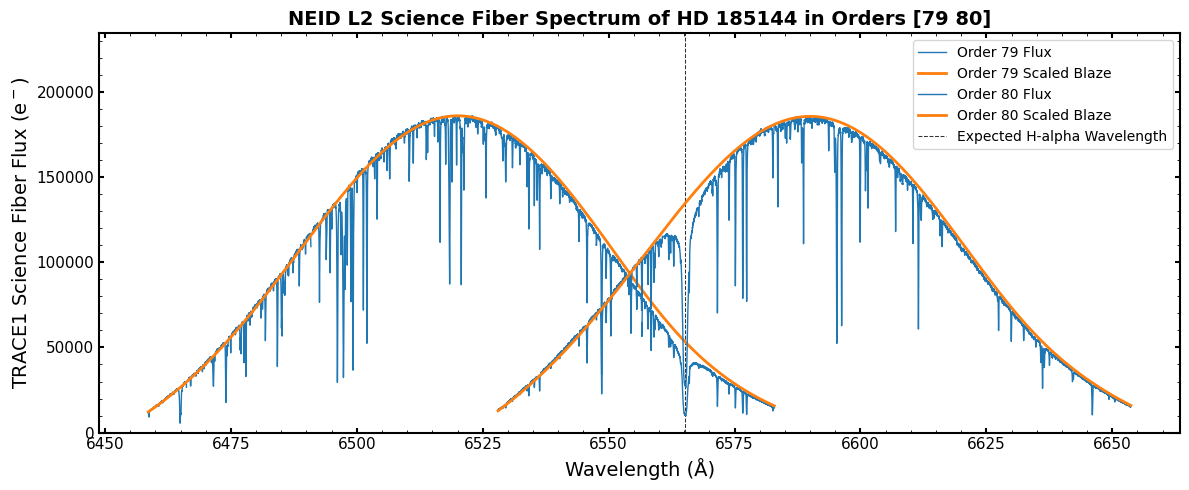

In [9]:
# Let's make a plot!
fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharex=True)

# Set the science trace ID number, 1, and extract the relevant data arrays to variables
trace_num = 1
wave = sl2[f'TRACE{trace_num}_WAVE'].data
flux = sl2[f'TRACE{trace_num}_FLUX'].data
blaze = sl2[f'TRACE{trace_num}_BLAZE'].data

# Let's also scale the blaze to match the flux maxima per order for visualization
blaze_scaled = blaze * (np.nanmax(flux, axis=1) / np.nanmax(blaze, axis=1))[:,np.newaxis]

# Go through and plot both of the H-alpha orders:
for order in orders_halpha:
    ax.plot(wave[order], flux[order], color='tab:blue', linestyle='-', lw=1.0, label=f'Order {order} Flux')
    ax.plot(wave[order], blaze_scaled[order], color='tab:orange', linestyle='-', lw=2.0, label=f'Order {order} Scaled Blaze')

# Let's also plot a vertical line at the expected wavelength
ax.axvline(x=halpha_wavelength_shifted, c='#323232', lw=0.75, ls='--', label='Expected H-alpha Wavelength', zorder=1)

# Set up all the labels and such
ax.set_xlabel('Wavelength (\u212B)')
ax.set_ylabel(f'TRACE{trace_num} Science Fiber Flux (e$^-$)')
ax.set_title(f"NEID L2 Science Fiber Spectrum of {sl2['PRIMARY'].header['OBJECT']} in Orders {orders_halpha}", fontsize=14, fontweight='bold')

ax.legend(loc='upper right')

ax.set_ylim(0, np.nanmax(flux) * 1.1)

plt.tight_layout()
plt.show()

Hey! That looks like a very nice spectrum with a deep absorption line at the expected H-alpha wavelength!

This example is simple, but hopefully shows the ease with which you can find and inspect spectral regions of interest using the standardized data products.

It looks like Order 80 has the H-alpha line closer to the middle of the order, where its signal-to-noise is better. Let's plot just order 80 and zoom in on the H-alpha line

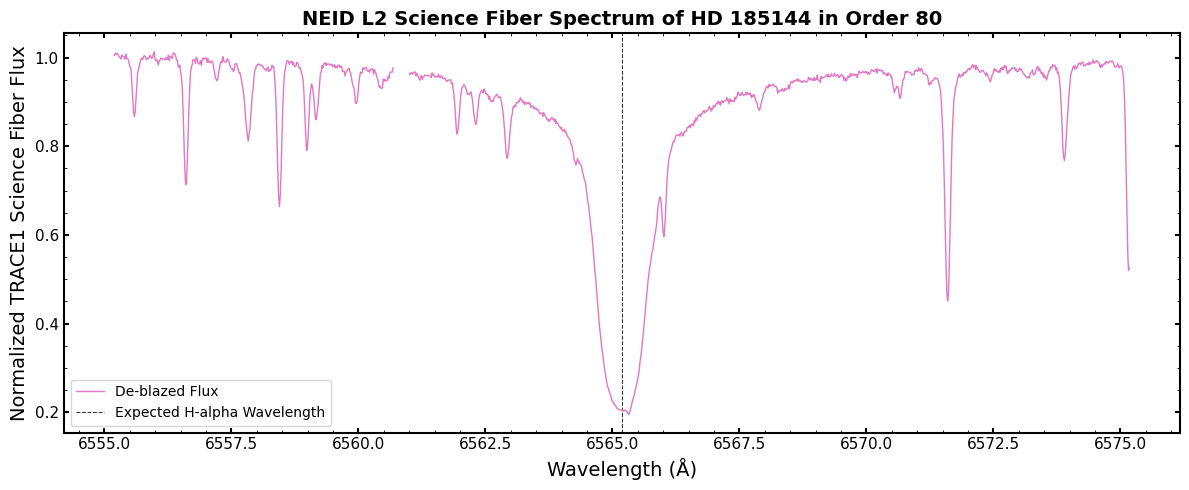

In [10]:
# Let's make a plot!
fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharex=True)

# We can set the order here
order = 80

# Set the science trace ID number, 1, and extract the relevant data arrays to variables
trace_num = 1
wave = sl2[f'TRACE{trace_num}_WAVE'].data[order]
flux = sl2[f'TRACE{trace_num}_FLUX'].data[order]
blaze = sl2[f'TRACE{trace_num}_BLAZE'].data[order]

# Let's also scale the blaze to match the flux maxima per order for visualization
blaze_scaled = blaze * (np.nanmax(flux) / np.nanmax(blaze))

# We can zoom in and only plot a spectral region close to H-alpha, let's say +/- 10 Angstrom
plot_indices = np.where((np.abs(wave - halpha_wavelength_shifted) < 10))[0]

# Let's also divide out the scaled blaze function for this order, so we have a relatively flat spectral continuum
ax.plot(wave[plot_indices], (flux / blaze_scaled)[plot_indices], color='tab:pink', linestyle='-', lw=1.0, label=f'De-blazed Flux')

# Let's also plot a vertical line at the expected wavelength
ax.axvline(x=halpha_wavelength_shifted, c='#323232', lw=0.75, ls='--', label='Expected H-alpha Wavelength', zorder=1)

# Set up all the labels and such
ax.set_xlabel('Wavelength (\u212B)')
ax.set_ylabel(f'Normalized TRACE{trace_num} Science Fiber Flux')
ax.set_title(f"NEID L2 Science Fiber Spectrum of {sl2['PRIMARY'].header['OBJECT']} in Order {order}", fontsize=14, fontweight='bold')

ax.legend()

plt.tight_layout()
plt.show()

Here we can see in detail the H-alpha line, exactly where expected as shown by the vertical dashed line.

The line is expectedly very deep and very broad. There are also a slew of other lines in the region.

However, not all of those lines are from the star itself! Some of those are telluric absorption lines. 
They are the signature of Earth's atmosphere absorbing some of the incoming star light. It sure would be nice to remove those...

### NEID's standard L2 telluric absorption model and correction

Luckily, the NEID pipeline provides a model of telluric absorption across the spectrum. 
This is provided in the `TRACE1_TELLURIC` standard data format extension. It has the same data shape 
as the TRACE flux arrays. 

Let's take a look at the telluric absorption model in this H-alpha region!

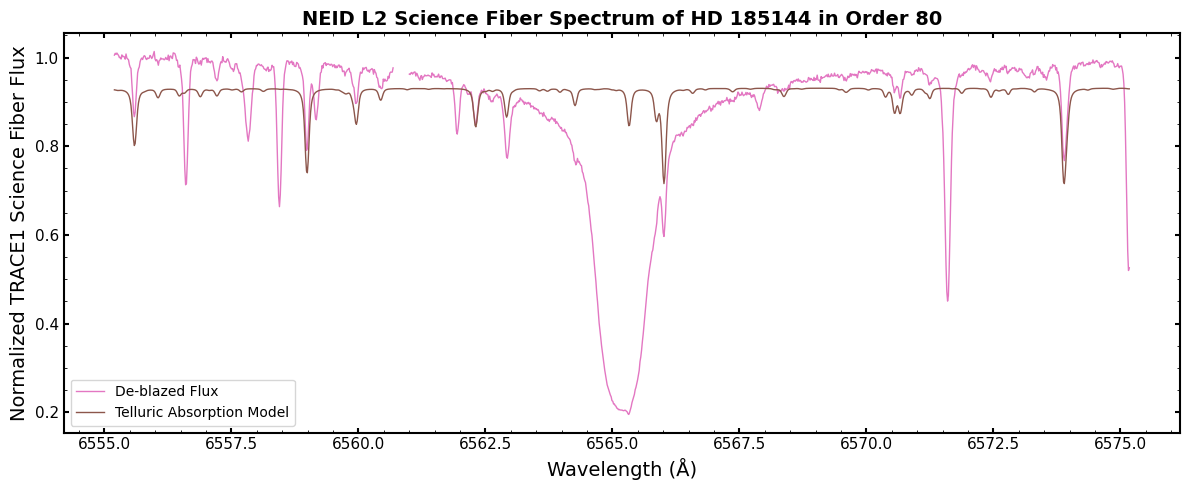

In [11]:
# Let's make a plot!
fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharex=True)

# We can set the order here
order = 80

# Set the science trace ID number, 1, and extract the relevant data arrays to variables
trace_num = 1
wave = sl2[f'TRACE{trace_num}_WAVE'].data[order]
flux = sl2[f'TRACE{trace_num}_FLUX'].data[order]
blaze = sl2[f'TRACE{trace_num}_BLAZE'].data[order]
blaze_scaled = blaze * (np.nanmax(flux) / np.nanmax(blaze))

# Let's also set this order's telluric model to a variable
telluric_model = sl2[f'TRACE{trace_num}_TELLURIC'].data[order]

# We can zoom in and only plot a spectral region close to H-alpha, let's say +/- 10 Angstrom
plot_indices = np.where((np.abs(wave - halpha_wavelength_shifted) < 10))[0]

# Let's plot the spectrum with the normalized blaze removed and the telluric model on top
ax.plot(wave[plot_indices], (flux / blaze_scaled)[plot_indices], color='tab:pink', linestyle='-', lw=1.0, label=f'De-blazed Flux')
ax.plot(wave[plot_indices], telluric_model[plot_indices], color='tab:brown', linestyle='-', lw=1.0, label=f'Telluric Absorption Model')

# Set up all the labels and such
ax.set_xlabel('Wavelength (\u212B)')
ax.set_ylabel(f'Normalized TRACE{trace_num} Science Fiber Flux')
ax.set_title(f"NEID L2 Science Fiber Spectrum of {sl2['PRIMARY'].header['OBJECT']} in Order {order}", fontsize=14, fontweight='bold')

ax.legend()

plt.tight_layout()
plt.show()

Here, the telluric absorption model is plotted in brown. You can see that plenty of the lines in this 
spectral region are actually telluric contamination, including multiple that directly overlap the H-alpha line!

Some important notes to keep in mind about the NEID telluric absorption model:
- It is generated from line by line radiative transfer modeling for an observation's airmass and 
best fit water vapor column. This model is then convolved with a model of NEID's instrumental line 
profile. It is not a completely accurate model (e.g., it does not capture asymmetries in the instrumental 
line profile), but it performs fairly well!
- It combines both line absorption and continuum absorption. That is why the overall level of the telluric model is below 1.
- *The NEID pipeline only provides a telluric model for zero-indexed orders 55-110* because the 
instrumental line profile has not been characterized outside of that range yet. The value of the 
provided telluric model in those orders is just set to 1.

Let's apply the correction by dividing the observed flux by the model to see how it does!

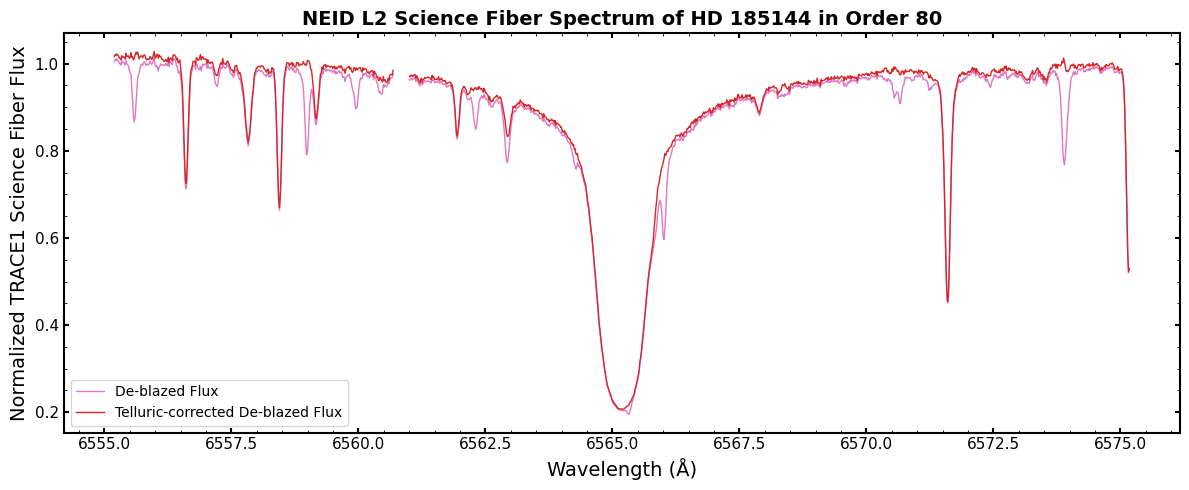

In [12]:
# Let's make a plot!
fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharex=True)

# We can set the order here
order = 80

# Set the science trace ID number, 1, and extract the relevant data arrays to variables
trace_num = 1
wave = sl2[f'TRACE{trace_num}_WAVE'].data[order]
flux = sl2[f'TRACE{trace_num}_FLUX'].data[order]
blaze = sl2[f'TRACE{trace_num}_BLAZE'].data[order]
blaze_scaled = blaze * (np.nanmax(flux) / np.nanmax(blaze))

# Let's also set this order's telluric model to a variable, and normalize it so it only contains the line absorption
telluric_model = sl2[f'TRACE{trace_num}_TELLURIC'].data[order]
telluric_model_scaled = telluric_model / np.nanmax(telluric_model)

# We can zoom in and only plot a spectral region close around H-alpha, let's say +/- 15 Angstrom
plot_indices = np.where((np.abs(wave - halpha_wavelength_shifted) < 10))[0]

# We can plot the deblazed spectrum and the deblazed, telluric-corrected spectrum
ax.plot(wave[plot_indices], (flux / blaze_scaled)[plot_indices], color='tab:pink', linestyle='-', lw=1.0, label=f'De-blazed Flux')
ax.plot(wave[plot_indices], (flux / blaze_scaled / telluric_model_scaled)[plot_indices], color='tab:red', linestyle='-', lw=1.0, label=f'Telluric-corrected De-blazed Flux')

# Set up all the labels and such
ax.set_xlabel('Wavelength (\u212B)')
ax.set_ylabel(f'Normalized TRACE{trace_num} Science Fiber Flux')
ax.set_title(f"NEID L2 Science Fiber Spectrum of {sl2['PRIMARY'].header['OBJECT']} in Order {order}", fontsize=14, fontweight='bold')

ax.legend()

plt.tight_layout()
plt.show()

Here, the telluric-corrected spectrum is plotted in red and the un-corrected spectrum is in pink. 
We've normalized the telluric model before removing it so that only the line absorption is removed and 
the two spectra are on top of each other.

The correction performs very well! The telluric lines that overlap the broad H-alpha line are cleanly removed.

In general, most of the lines are removed without much residual noise. Some lines, 
like the one just shy of 6574 Angstrom, have a correction residual. This is likely due to imperfections 
in the radiative transfer model.

Regardless, this is a handy and standardized way to remove telluric contamination from your NEID spectra!

---
# Level 3: Stitched 1D Spectrum

Level 3 data contains a stitched 1D spectrum on a common wavelength grid with constant velocity spacing. The stitching process:
1. Divides out the blaze function
2. Resamples each order onto a common wavelength grid
3. Combines overlapping regions using inverse-variance weighting

## Creating L3 from L2

L3 is created from an RVData-standard L2 file.

In [13]:
# Create L3 from the standard L2 file
neid_l2 = RV2.from_fits(l2_standard_file)
neid_l3 = RV3()
neid_l3.convert_level2_to_level3(neid_l2)

# Save to FITS file
l3_standard_file = neid_l3.to_fits()
print(f"Created {l3_standard_file}")

Created neid_SL3_20231010T020006.fits


## Using L3 Data

### Reading the L3 File

In [14]:
# Open the standardized L3 file
sl3 = fits.open(l3_standard_file)

# List extensions using the extension description table
Table(sl3['EXT_DESCRIPT'].data).pprint_all()

         Name                                         Description                                
---------------------- --------------------------------------------------------------------------
               PRIMARY                                        EPRV Standard FITS HEADER (no data)
     INSTRUMENT_HEADER                                      Inherited instrument header (no data)
               RECEIPT                  Table of operations that have been performed on this file
            DRP_CONFIG               Pipeline details (settings etc) to go from native data to L2
          EXT_DESCRIPT                                Table describing contents of each extension
           ORDER_TABLE             Table capturing the wavelength extent of each order in Trace 1
STITCHED_CORR_SCI_FLUX Order stitched and blaze-corrected flux co-added across all science traces
STITCHED_CORR_SCI_WAVE        Order stitched barycentric- and drift-corrected wavelength solution
 STITCHED_CORR_SCI_V

### Understanding L3 Extensions

For NEID with one science fiber, the stitched spectrum is stored in `STITCHED_CORR_SCI_*` extensions:
- `STITCHED_CORR_SCI_WAVE/FLUX/VAR`: Science fiber

In [15]:
# Check which STITCHED extensions are present
stitched_exts = [hdu.name for hdu in sl3 if 'STITCHED' in hdu.name]
print("Stitched spectrum extensions:")
for ext in stitched_exts:
    print(f"  {ext}")

Stitched spectrum extensions:
  STITCHED_CORR_SCI_FLUX
  STITCHED_CORR_SCI_WAVE
  STITCHED_CORR_SCI_VAR


### Plotting the Stitched Spectrum

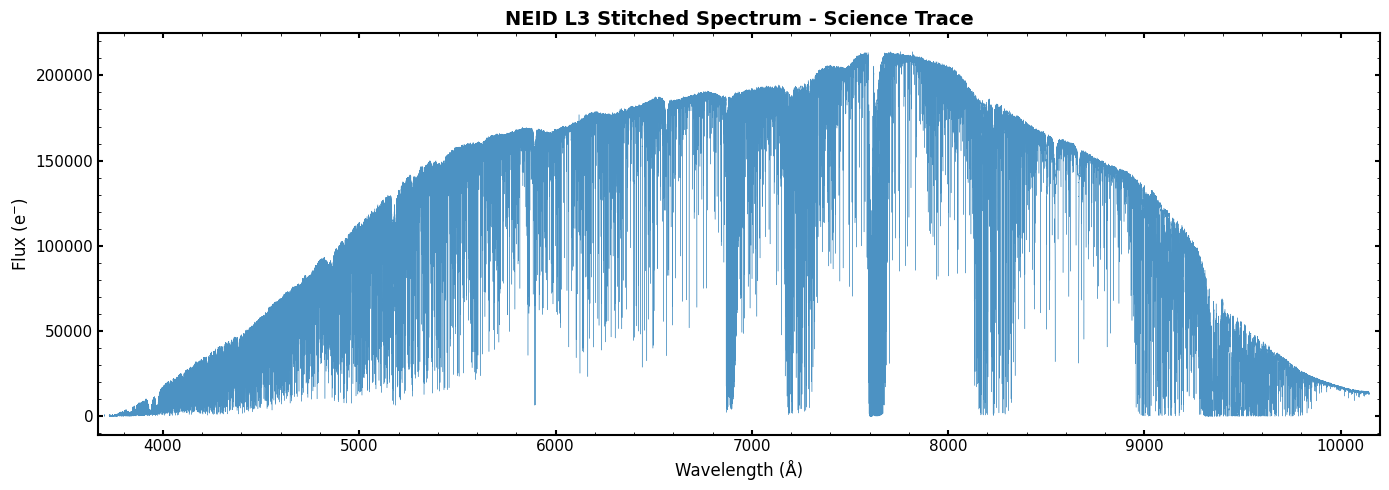


Wavelength range: 3670.0 - 10200.0 Angstroms
Number of pixels: 493473


In [16]:
# Plot the stitched spectrum for one trace
wave_ext = "STITCHED_CORR_SCI_WAVE"
flux_ext = "STITCHED_CORR_SCI_FLUX"
wave_l3 = sl3[wave_ext].data
flux_l3 = sl3[flux_ext].data

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(wave_l3, flux_l3, color='tab:blue', linestyle='-', lw=0.3, alpha=0.8)
ax.set_xlabel('Wavelength (\u212B)', fontsize=12)
ax.set_ylabel('Flux (e$^{-}$)', fontsize=12)
ax.set_title(f'NEID L3 Stitched Spectrum - Science Trace', fontsize=14, fontweight='bold')

# Zoom inset
ax.set_xlim(wave_l3[np.isfinite(wave_l3)].min(), wave_l3[np.isfinite(wave_l3)].max())
plt.tight_layout()
plt.show()

print(f"\nWavelength range: {np.nanmin(wave_l3):.1f} - {np.nanmax(wave_l3):.1f} Angstroms")
print(f"Number of pixels: {len(wave_l3)}")


### Zoomed View of Spectral Features

Let's again zoom in on the H-alpha spectral line. Here we plot the H-alpha line wavelength (vertical dashed line) without correcting for the object's systemic radial velocity

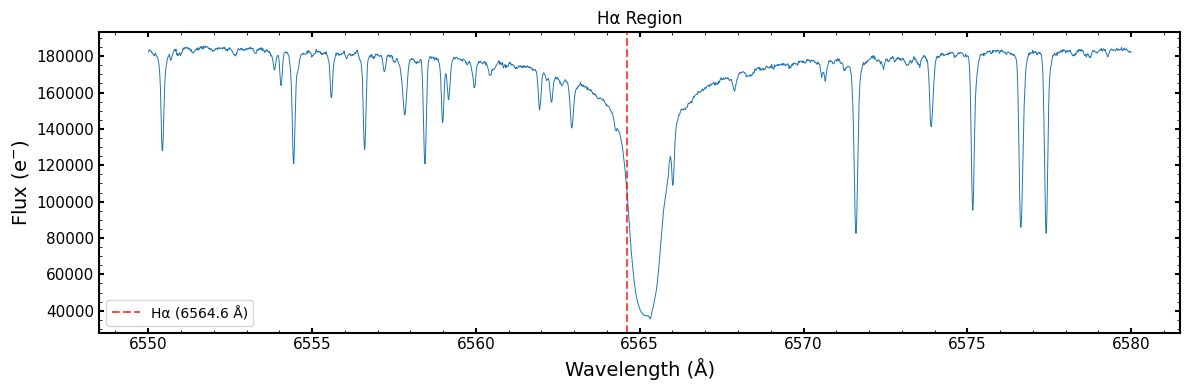

In [17]:
# Zoom in on H-alpha region
if wave_ext in [hdu.name for hdu in sl3]:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # H-alpha region
    mask = (wave_l3 > 6550) & (wave_l3 < 6580)
    ax.plot(wave_l3[mask], flux_l3[mask], color='tab:blue', linestyle='-', lw=0.7)
    ax.axvline(6564.6, color='red', ls='--', alpha=0.7, label='H\u03B1 (6564.6 \u212B)')
    ax.set_xlabel('Wavelength (\u212B)')
    ax.set_ylabel('Flux (e$^{-}$)')
    ax.set_title('H\u03B1 Region', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
# Level 4: Radial Velocity Measurements and Other Derived Products

Level 4 data contains radial velocity (RV) and ancillary measurements derived from the spectra. These include:
- Combined RV with uncertainty
- Per-order RVs
- Per-order cross correlation functions from which RVs are measured
- Activity indicators

## Creating L4 from Native NEID L2

L4 is created from native pipeline outputs that contain RV measurements. For NEID, the native L2 file includes CCF-derived RVs.

In [18]:
# Create L4 from native NEID L2 file (which contains RV measurements)
neid_l4 = RV4.from_fits(native_l2_file, instrument="NEID")

# Save to FITS file
l4_standard_file = neid_l4.to_fits()
print(f"Created {l4_standard_file}")

Created neid_SL4_20231010T020006.fits


## Using L4 Data

### Reading the L4 File

The standard L4 file has additional information added to the primary 
header regarding the radial velocity measurement.

In [19]:
# Let's read back in the standard L4 file
sl4 = fits.open(l4_standard_file)

# Examine primary header for RV info
hdr4 = sl4[0].header
print(f"Object: {hdr4['OBJECT']}")
print(f"Observation time (BJD): {hdr4['BJDTDB']}")
print(f"Radial Velocity: {hdr4['RV']*1000:.5f} m/s")
print(f"Radial Velocity Error (m/s): {hdr4['RVERR']*1000:.5f} m/s")
print(f"Radial Velocity Measurement Method: {hdr4['RVMETHOD']}")

Object: HD 185144
Observation time (BJD): 2460227.586673037
Radial Velocity: 26731.33691 m/s
Radial Velocity Error (m/s): 0.25687 m/s
Radial Velocity Measurement Method: CCF


The L4 primary header includes an RV value and uncertainty for the observation, along with the 
method used for RV measurement. This RV header value is the one recommended for use by the instrument 
team for a "roll-up" RV of a given observation. The header also includes the corresponding time of 
the RV.

In the case of NEID, the RVs are measured with CCFs. The primary header RV value are the native 
CCFRVMOD values, which are made by coadding individual order CCFs that are weighted based on the 
target SED and instrument throughput.

### L4 also includes an extension description table, like L2

In [20]:
# Write out the extension description table
Table(sl4['EXT_DESCRIPT'].data).pprint_all()

       Name                               Description                         
----------------- ------------------------------------------------------------
          PRIMARY                          EPRV Standard FITS HEADER (no data)
INSTRUMENT_HEADER                   Inherited NEID instrument header (no data)
          RECEIPT    Table of operations that have been performed on this file
       DRP_CONFIG Pipeline details (settings etc) to go from native data to L2
     EXT_DESCRIPT                  Table describing contents of each extension
              RV1 Order-wise RV measurement table for NEID Science fiber trace
             CCF1                 Order-wise CCFs for NEID Science fiber trace
     DIAGNOSTICS1   Table of activity diagnostics for NEID science fiber trace


The other extensions include more granular RV information, such as the order-wise RVs and CCFs, as 
well as ancillary measurements like activity indicators.

### Examining the Order-wise RVs in the RV1 Extension

The `RV1` extension contains a table of the NEID order-wise RVs. The `1` refers to the spectral trace 
from which the RVs were calculated, which for NEID is the Trace 1 science fiber.

In [21]:
# Let's set the order-wise RV table as an astropy Table object
order_rv_table = Table(sl4['RV1'].data)

# Here let's print just a part of the table (rows 9 through 14)
order_rv_table[9:15].pprint_all()

     BJD_TDB              RV        RV_ERR        BERV           WAVE_START          WAVE_END      PIXEL_START PIXEL_END ORDER_INDEX ECHELLE_ORDER       WEIGHT      
----------------- ----------------- ------ ----------------- ------------------ ------------------ ----------- --------- ----------- ------------- ------------------
2460227.586733954               nan    nan 1.056088165714715                nan                nan         nan       nan           9           164                0.0
2460227.586733954               nan    nan 1.056088165714715                nan                nan         nan       nan          10           163  1.198329993108328
2460227.586733954 26.71503980582002    nan 1.056088165714715 3775.8065117012347 3800.0659493553376      3007.0    6082.0          11           162 0.9273202655362364
2460227.586733954 26.79718058753021    nan 1.056088165714715  3799.923601807259 3823.0455982184685      3083.0    5995.0          12           161 0.9710176047748902
2460

Here we print just a part of the `RV1` table, showing zero-indexed orders 9 through 14. Each row is a 
NEID spectral order and has columns including that order's flux-weighted BJD, CCF-measured RV, 
wavelength extent that contributes to the RV measurement, and a weight that is applied to that order's
CCF when creating the roll-up RV in the primary header

You can see that orders 9 and 10 have no RVs: these are orders that do not have RVs measured. 
Various orders across NEID's bandpass that have extracted spectra do not have RVs. For example, many 
of the reddest orders do not have RVs because they are excluded in the CCF mask from having too much 
telluric contamination.

*These order-wise RV values are stored in header entries in the native NEID file, so this table makes 
it way easier to access the order-wise measurements!*

Note that we do not calculate per-order RV errors.

#### We can also plot the order-wise RVs

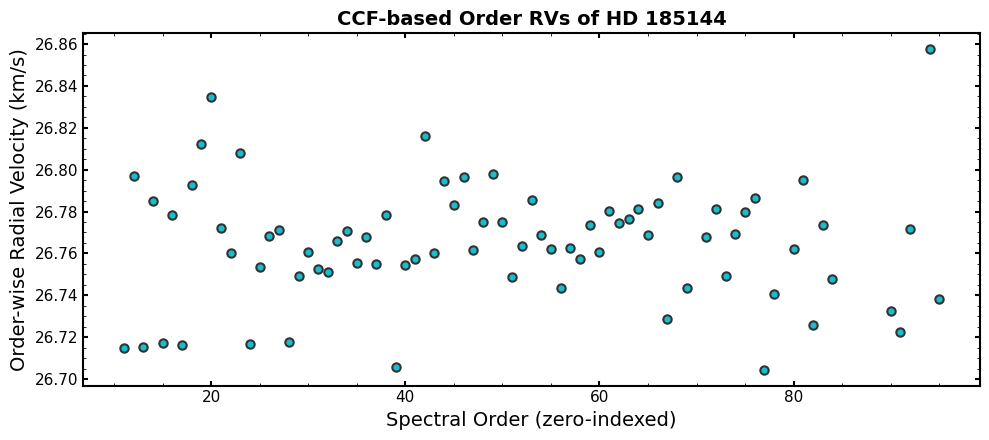

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10,4.5), sharex=True)

ax.plot(order_rv_table["ORDER_INDEX"], order_rv_table["RV"], "o", color="tab:cyan", ms=6, mec='#323232', mew=1.5)

# Labels
ax.set_xlabel("Spectral Order (zero-indexed)")
ax.set_ylabel("Order-wise Radial Velocity (km/s)")
ax.set_title(f"CCF-based Order RVs of {sl4['PRIMARY'].header['OBJECT']}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Looking at order-wise RVs is a useful way to diagnose any potential issues with your roll-up RV 
value.

This particular observation is well-behaved, but you can look for orders that have particularly bad 
outlier RVs or trends as a function of spectral order/wavelength.

For example with NEID, you can look for differences in the RVs derived from orders that use the 
laser frequency comb for wavelength calibration and those that use the Thorium-Argon lamp. 
The LFC-using orders are 58-110 (zero-indexed) for observations before September 2024 and orders 
40-110 for observations after September 2024. 

### Individual order CCFs

The standard L4 file also includes the per-order computed CCFs in the `CCF1` extension.

The `CCF1` header includes information about the CCFs:

In [23]:
sl4['CCF1'].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  804                                                  
NAXIS2  =                  122                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
VELSTART=             -73.4236                                                  
VELSTEP =                 0.25                                                  
CCFMASK = 'G8_espresso.txt'                                                     
VELNSTEP=                  804                                                  
EXTNAME = 'CCF1    '           / extension name                                 

The file name for the spectral line mask used to calculate the CCF is given by the `CCFMASK` entry.

The data for this extension is just the CCF values. You can reconstruct the velocity array that the 
CCF was computed over using the header entries `VELSTART`, `VELSTEP`, and `VELNSTEP`. The CCF data 
array has shape (number of orders, `VELNSTEP`).

Here let's reconstruct the CCF velocity array and then plot the CCF for one order:

In [24]:
# We'll set the velocity starting value to its own variable
ccf_vel_start = sl4["CCF1"].header["VELSTART"]

# And compute the ending velocity using the start, step, and number of steps header entries
ccf_vel_end = sl4["CCF1"].header["VELSTART"] + sl4["CCF1"].header["VELSTEP"] * sl4["CCF1"].header["VELNSTEP"]

# And create the velocity array from these values
ccf_vel_arr = np.arange(ccf_vel_start, ccf_vel_end, sl4["CCF1"].header["VELSTEP"])

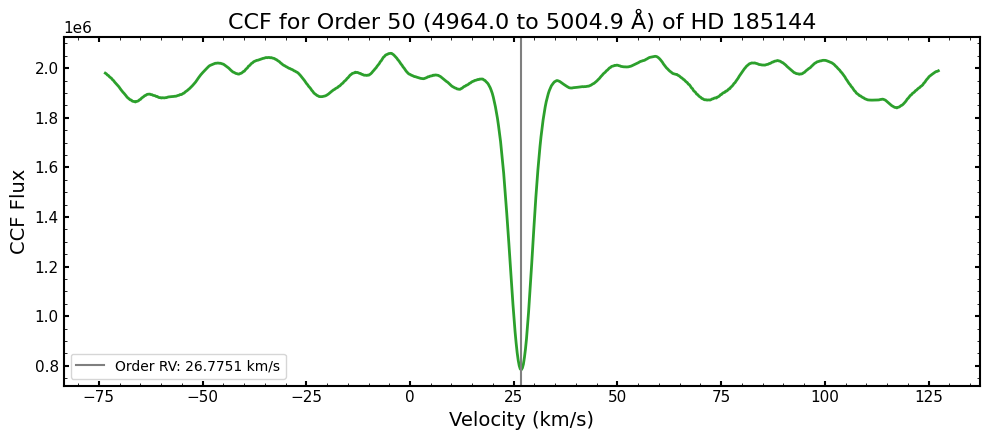

In [25]:
# Now let's plot the CCF for an order
order = 50

fig, ax = plt.subplots(1, 1, figsize=(10,4.5), sharex=True)

ax.plot(ccf_vel_arr, sl4["CCF1"].data[order], "-", color="tab:green", lw=2.0)

# And a vertical line at that order's RV value
ax.axvline(x=order_rv_table["RV"][order], c='tab:gray', lw=1.5, ls='-', label=f'Order RV: {order_rv_table["RV"][order]:.4f} km/s')

ax.set_xlabel('Velocity (km/s)')
ax.set_ylabel('CCF Flux')
ax.set_title(f"CCF for Order {50} ({order_rv_table["WAVE_START"][order]:.1f} to {order_rv_table["WAVE_END"][order]:.1f} \u212B) of {sl4['PRIMARY'].header['OBJECT']}", fontsize=16)

ax.legend()

plt.tight_layout()
plt.show()

The minimum of the CCF and the order RV value from the `RV1` table directly coincide!

This is another avenue for inspecting the quality of your RVs. You could identify orders that might 
have outlier RVs in the `RV1` table and then inspect their CCFs directly.

### Activity diagnostic measurements

The standard L4 file also contains stellar activity diagnostic measurements that are output by the 
NEID data pipeline. These are stored in the `DIAGNOSTICS1` extension. Let's take a look!

In [26]:
Table(sl4['DIAGNOSTICS1'].data).pprint_all()

   metric_name           value              uncertainty      
----------------- -------------------- ----------------------
           CaIIHK  0.17541366583790996  0.0002495382532907082
  CaIIHK_tellcorr  0.17541366583790996  0.0002495382532907082
              HeI   1.0221921751942795  0.0004536309111715093
     HeI_tellcorr    1.032817634465483  0.0004584953742246589
              NaI  0.24106207913372552 0.00013738443185951513
     NaI_tellcorr  0.24685779738344446 0.00014074525848053042
         Halpha06  0.23151522477468936 0.00017433092730222092
Halpha06_tellcorr  0.23355674137989674  0.0001759410175867868
         Halpha16   0.4206121690911927 0.00014536501949436982
Halpha16_tellcorr   0.4259436216245271  0.0001473136305586283
              CaI   0.8731594140309632 0.00044222389677976394
     CaI_tellcorr   0.8682649369327627   0.000439739147699434
           CaIRT1   0.5031829193001701 0.00027932577851676627
  CaIRT1_tellcorr  0.49972510948400634  0.0002774161203393202
        

The values included are a mix of spectral line indices and CCF-derived activity diagnostics. 

**The last two rows are the CCF-based measurements:** the FWHM of the best-fit Gaussian used to measure 
the RV and the bisector inverse slope. Note that the FWHM only has a corresponding uncertainty for 
data that are reduced with the NEID DRP v1.5 and after.

**The rest of the rows are spectral line indices.** Each one has two values: with and without the NEID 
telluric correction applied. The NEID team recommends using the version with the telluric 
correction applied (having suffix `_tellcorr`). This will reduce contamination when doing time 
series analysis of activity indicators (such as yearly aliasing). Some of the indices, like Ca II 
HK, have the same value for the corrected and un-corrected versions. This is because they are in 
a part of the spectrum that does not have a telluric model defined (outside of orders 55-110).

The units for the FWHM and BIS are km/s, and the spectral indices are unitless (since they are 
relative flux values).

Detailed information about the stellar activity diagnostics measurement can be found in the 
documentation for the NEID data reduction pipeline here: 
[https://neid.ipac.caltech.edu/docs/NEID-DRP/algorithms.html#stellar-activity-info](https://neid.ipac.caltech.edu/docs/NEID-DRP/algorithms.html#stellar-activity-info)

---
# NEID Tutorial Summary

This tutorial demonstrated how to:

1. **Create L2** from native NEID L2 file using `RV2.from_fits()`
2. **Use L2 data**: access headers, examine extensions, find wavelengths in the spectrum, plot spectra, and apply the telluric model
3. **Create L3** from standard L2 using `neid_l2 = RV2.from_fits()` and `RV3().convert_level2_to_level3(neid_l2)`
4. **Use L3 data**: access stitched spectra, examine spectral features
5. **Create L4** from native NEID L2 using `RV4.from_fits()`
6. **Use L4 data**: access RV measurements, look at per-order RVs and CCFs, and examine stellar activity diagnostic information

The standardized data format allows consistent access patterns across all EPRV instruments!

In [27]:
# Clean up - close FITS files
sl2.close()
sl3.close()
sl4.close()